In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split

df=pd.read_csv('creditcard.csv')

In [2]:
df.shape

(284807, 31)

In [3]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
df['Class'].value_counts()/df.shape[0] * 100

Class
0    99.827251
1     0.172749
Name: count, dtype: float64

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [21]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [22]:
df.isnull().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [3]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
253956,156510.0,0.085162,0.837574,-0.027908,-0.770661,0.810984,-0.599795,0.995246,-0.138900,-0.008535,...,-0.302297,-0.680496,-0.013509,-0.779984,-0.398731,0.190225,0.249173,0.089505,5.38,0
57633,47990.0,-1.322744,1.553042,0.380158,-0.298407,-0.369915,-0.249638,-0.202689,1.049318,-0.599053,...,-0.189541,-0.758598,-0.017136,-0.545948,-0.049221,0.117770,0.120179,0.023036,8.99,0
168398,119208.0,-0.394017,1.329406,-0.351200,-0.449873,0.407579,-0.771826,0.562334,-1.845648,0.140629,...,1.892201,0.816012,0.063080,-0.073699,-0.769856,-0.200034,0.593869,0.331994,19.10,0
247067,153444.0,-0.233607,0.957730,-2.053453,-1.505444,2.792908,3.168899,0.025368,1.345372,-0.331767,...,-0.288399,-0.917790,0.183824,0.591152,-0.396548,0.166377,0.117611,0.008704,9.99,0
114607,73546.0,1.212614,-0.980033,1.397129,-0.970251,-1.745327,0.121680,-1.435465,0.270606,-0.495180,...,-0.070851,0.282534,0.116138,0.295202,-0.247789,1.491684,-0.018826,0.013882,26.47,0


In [4]:
df.drop(columns=['Time'], inplace=True)

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
# X = features, y = imbalanced target labels
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['Class']), df['Class'], test_size=0.2, random_state=42, stratify=df['Class']
)

In [8]:
#  Stratified K-Fold Cross-Validation on Training Data
print("--- Starting Cross-Validation ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    # Split training data into fold training and fold validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Initialize model with class_weight='balanced' to handle imbalance
    model = RandomForestClassifier(class_weight="balanced", random_state=42)
    model.fit(X_fold_train, y_fold_train)

    # Evaluate on fold validation data using F1-score
    val_preds = model.predict(X_fold_val)
    # Target class 1 for tracking minority class performance
    #from sklearn.metrics import f1_score

    score = f1_score(y_fold_val, val_preds)
    fold_scores.append(score)
    print(f"Fold {fold} - Minority Class F1-Score: {score:.4f}")

print(f"Mean CV F1-Score: {np.mean(fold_scores):.4f}\n")


# 4. Final Training and Test Set Evaluation
print("--- Final Evaluation on Test Set ---")
# Train model on the entire training pool
final_model = RandomForestClassifier(class_weight="balanced", random_state=42)
final_model.fit(X_train, y_train)

# Predict on the untouched test holdout
test_preds = final_model.predict(X_test)

print("F1 score:")
print(f1_score(y_test, test_preds))
# Print metrics (Focus on Precision, Recall, and F1-score for class 1)
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))
print("\nClassification Report:")
print(classification_report(y_test, test_preds))


--- Starting Cross-Validation ---
Fold 1 - Minority Class F1-Score: 0.8345
Fold 2 - Minority Class F1-Score: 0.8148
Fold 3 - Minority Class F1-Score: 0.8201
Fold 4 - Minority Class F1-Score: 0.8414
Fold 5 - Minority Class F1-Score: 0.8531
Mean CV F1-Score: 0.8328

--- Final Evaluation on Test Set ---
F1 score:
0.8390804597701149
Confusion Matrix:
[[56861     3]
 [   25    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
confusion_matrix(y_test, test_preds)

array([[56861,     3],
       [   25,    73]], dtype=int64)

In [10]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

In [11]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np

#  Stratified K-Fold Cross-Validation on Training Data
print("--- Starting Cross-Validation ---")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

    # Split training data into fold training and validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Handle class imbalance
    scale_pos_weight = (
        (y_fold_train == 0).sum() / (y_fold_train == 1).sum()
    )

    # Initialize XGBoost model
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8
    )

    # Train model
    model.fit(X_fold_train, y_fold_train)

    # Predict on validation fold
    val_preds = model.predict(X_fold_val)

    # Evaluate using F1-score
    score = f1_score(y_fold_val, val_preds)
    fold_scores.append(score)

    print(f"Fold {fold} - Minority Class F1-Score: {score:.4f}")

print(f"\nMean CV F1-Score: {np.mean(fold_scores):.4f}\n")


#  Final Training and Test Set Evaluation
print("--- Final Evaluation on Test Set ---")

# Compute imbalance ratio on full training data
final_scale_pos_weight = (
    (y_train == 0).sum() / (y_train == 1).sum()
)

# Train final model
final_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=final_scale_pos_weight,
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

final_model.fit(X_train, y_train)

# Predict on test set
test_preds = final_model.predict(X_test)

# Evaluation
print("F1 score:")
print(f1_score(y_test, test_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_preds))

print("\nClassification Report:")
print(classification_report(y_test, test_preds))

--- Starting Cross-Validation ---
Fold 1 - Minority Class F1-Score: 0.7879
Fold 2 - Minority Class F1-Score: 0.8212
Fold 3 - Minority Class F1-Score: 0.7922
Fold 4 - Minority Class F1-Score: 0.8092
Fold 5 - Minority Class F1-Score: 0.8497

Mean CV F1-Score: 0.8120

--- Final Evaluation on Test Set ---
F1 score:
0.8038277511961722

Confusion Matrix:
[[56837    27]
 [   14    84]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.86      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.93      0.90     56962
weighted avg       1.00      1.00      1.00     56962



Training Shape: (227845, 30)
Testing Shape : (56962, 30)

Training Class Distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Starting Hyperparameter Tuning
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters
{'xgb__subsample': 1.0, 'xgb__n_estimators': 500, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0.3, 'xgb__colsample_bytree': 0.6, 'smote__k_neighbors': 3}

Best Cross Validation F1 Score:
0.8404

Threshold Tuning
Best Threshold: 0.85
Best F1: 0.8723

Final Evaluation

F1 Score      : 0.8723
ROC AUC Score : 0.9830
PR AUC Score  : 0.8681

Confusion Matrix:
[[56856     8]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg     

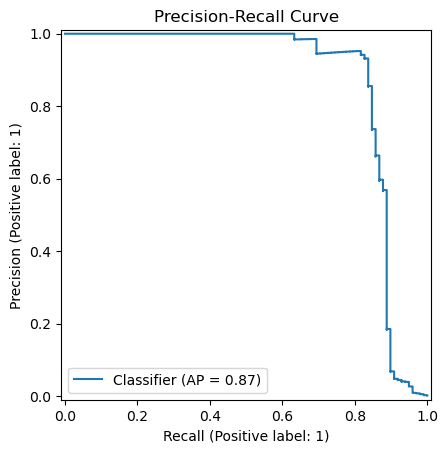


Top 20 Important Features:
   Feature  Importance
14     V14    0.233665
10     V10    0.231589
4       V4    0.127256
12     V12    0.117598
17     V17    0.064511
3       V3    0.039367
1       V1    0.018945
11     V11    0.018876
8       V8    0.012969
18     V18    0.010660
2       V2    0.010461
19     V19    0.009607
16     V16    0.009307
20     V20    0.008062
21     V21    0.007928
7       V7    0.007799
9       V9    0.007436
13     V13    0.006643
5       V5    0.006402
29  Amount    0.006063


In [12]:
# XGBoost + SMOTE + Hyperparameter Tuning
# Complete Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    PrecisionRecallDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


# TRAIN TEST SPLIT
print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

# PIPELINE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])
# HYPERPARAMETER SPACE

param_grid = {

    'smote__k_neighbors': [3, 5, 7],

    'xgb__n_estimators': [100, 200, 300, 500],

    'xgb__learning_rate': [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    'xgb__max_depth': [3, 4, 5, 6, 8],

    'xgb__min_child_weight': [1, 3, 5, 7],

    'xgb__subsample': [
        0.6,
        0.8,
        1.0
    ],

    'xgb__colsample_bytree': [
        0.6,
        0.8,
        1.0
    ],

    'xgb__gamma': [
        0,
        0.1,
        0.3,
        1
    ]
}

# STRATIFIED K-FOLD

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# RANDOMIZED SEARCH
print("\n==============================")
print("Starting Hyperparameter Tuning")
print("==============================")

random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_grid,

    n_iter=25,

    scoring='f1',

    cv=skf,

    verbose=2,

    random_state=42,

    n_jobs=-1
)
# TRAIN SEARCH

random_search.fit(
    X_train,
    y_train
)
# BEST RESULTS
print("\n==============================")
print("Best Parameters")
print("==============================")

print(random_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(random_search.best_score_, 4))


# BEST MODEL
best_model = random_search.best_estimator_
# THRESHOLD TUNING
print("\n==============================")
print("Threshold Tuning")
print("==============================")

test_probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(
    0.1,
    0.9,
    0.05
)

best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:

    preds = (
        test_probs > threshold
    ).astype(int)

    score = f1_score(
        y_test,
        preds
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best Threshold:", round(best_threshold, 2))
print("Best F1:", round(best_f1, 4))

# FINAL PREDICTIONS

final_preds = (
    test_probs > best_threshold
).astype(int)

# METRICS

print("\n==============================")
print("Final Evaluation")
print("==============================")

f1 = f1_score(
    y_test,
    final_preds
)

roc_auc = roc_auc_score(
    y_test,
    test_probs
)

pr_auc = average_precision_score(
    y_test,
    test_probs
)

print(f"\nF1 Score      : {f1:.4f}")
print(f"ROC AUC Score : {roc_auc:.4f}")
print(f"PR AUC Score  : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        final_preds
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_preds
    )
)

# PRECISION-RECALL CURVE

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probs
)

plt.title("Precision-Recall Curve")
plt.show()

# FEATURE IMPORTANCE

xgb_model = best_model.named_steps['xgb']

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 20 Important Features:")
print(feature_importance.head(20))